In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model as lm
clf = lm.Lasso(alpha = .1)
from functions import feature_selection, add_cross_terms, bootstrap_LOO


In [157]:
#Read in data file (see data_processing.ipynb for how this file is generated)
codes_and_CIs = pd.read_csv('combined_COPUS_CI_data.csv')

#Keep only Lec, CG, WG, OG, and SQ codes (see paper for discussion of feature selection)
#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

#The target variable is the effect size
######################################
target = codes_and_CIs['Effect Size'].to_numpy()

ES_variance = codes_and_CIs['Effect Size Variance'].to_numpy()

In [158]:
clf = lm.Lasso(alpha = .0001, max_iter = 10000)
clf.fit(data, target)
clf.coef_

array([ 0.92945761, -1.5259886 , -0.26366432,  0.86894394, -1.97285726,
        0.        ,  0.        , 25.28797937,  0.        ,  3.94476422,
       -1.84405801, -0.        , -2.47640313, -7.79953439,  1.61915561,
       -0.        , -3.5221378 , -0.        , -0.        ,  0.        ,
       -0.        ,  0.        , -0.        ,  0.        ,  0.        ,
        0.        ,  6.83196403, 27.25833948,  0.        ,  0.        ,
       -0.        , -0.        , -0.        , -0.        ,  0.79646702,
       -0.        ,  3.80484547, -0.        ,  0.        ])

In [159]:
#feature selection and aic functions are called in from functions.py
alpha = .001

maxits = 10000
#pick number of bootstrap samples and number of best fits to use for LOO predictions
bootstrap_n = 100
#pick number of feature selection order randomizations to use for each LOO fit
feature_selection_its = int(data.shape[0]*5)

#create empty arrays to store weights and predictions for each bootstrap sample, each best fit, and each data point
LOO_predictions = np.zeros(( bootstrap_n, data.shape[0]))
LOO_weights = np.zeros(( bootstrap_n, data.shape[0], data.shape[1]))
good_fit_AICs = np.zeros(( n_fits, data.shape[0] ))


#perform leave-one-out cross-validation for each of the best fits
for k in range(data.shape[0]): 
    cut_data = np.delete(data, k, axis=0)
    cut_truth = np.delete(target, k, axis=0)
    cut_weights = np.delete(1/np.sqrt(ES_variance), k, axis=0)

    for i in range(bootstrap_n):
        boot_inds = np.random.choice(cut_data.shape[0], int(cut_data.shape[0] * 0.95), replace=False)
        boot_data, boot_truth, boot_weights = cut_data[boot_inds], cut_truth[boot_inds], cut_weights[boot_inds]
        clf = lm.Ridge(alpha = alpha, max_iter = maxits)
        LOO_weights[i, k, :] = clf.fit(boot_data, boot_truth,sample_weight=boot_weights).coef_
        LOO_predictions[i, k] = clf.predict(data[k, :].reshape(1, -1))[0]
    #print(AICs[good_fits])




 LOO MAE: 0.33
 LOO R^2: 0.5

 Full fit MAE: 0.22
 Full fit R^2: 0.75

MAE removing high error: 0.33
R^2 removing high error: 0.47


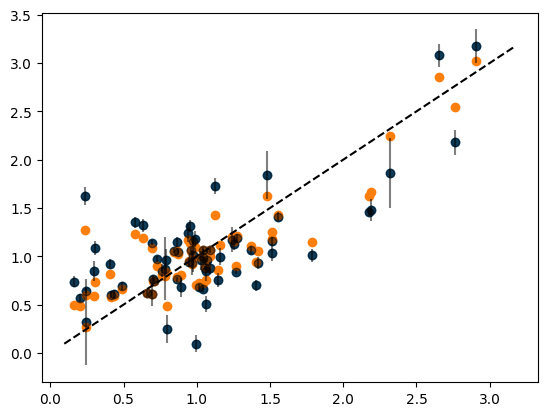

In [161]:
LOO_means = np.mean(LOO_predictions, axis=0)
LOO_stds = np.std(LOO_predictions, axis=0)

plot_target = 1*target
plt.scatter(plot_target, LOO_means,)
plt.plot([min(LOO_means), max(LOO_means)], [min(LOO_means), max(LOO_means)], color='k', ls='--')
plt.errorbar( plot_target, LOO_means, yerr=LOO_stds, fmt='o', color='k', alpha=0.5)
print(f' LOO MAE: {np.round(np.mean(np.abs(LOO_means - plot_target)), 2)}')
print(f' LOO R^2: {np.round(np.corrcoef(LOO_means, plot_target)[0, 1]**2, 2)}')

# show full fit
all_preds = np.zeros((bootstrap_n, data.shape[0]))
for i in range(bootstrap_n):
    boot_inds = np.random.choice(data.shape[0], int(data.shape[0] * 0.95), replace=False)
    boot_data, boot_truth, boot_weights = data[boot_inds], target[boot_inds], 1/np.sqrt(ES_variance)[boot_inds]
    clf = lm.Ridge(alpha = alpha, max_iter = maxits)
    all_preds[i] = clf.fit(boot_data, boot_truth, sample_weight=boot_weights).predict(data)
plt.scatter( target, np.mean(all_preds, axis=0),)
print('')
print(f' Full fit MAE: {np.round(np.mean(np.abs(np.mean(all_preds, axis=0) - plot_target)), 2)}')
print(f' Full fit R^2: {np.round(np.corrcoef(np.mean(all_preds, axis=0), plot_target)[0, 1]**2, 2)}')


print('')
low_error_inds = np.where(LOO_stds < .3)[0]
print(f'MAE removing high error: {np.round(np.mean(np.abs(LOO_means[low_error_inds] - plot_target[low_error_inds])), 2)}')
print(f'R^2 removing high error: {np.round(np.corrcoef(LOO_means[low_error_inds], plot_target[low_error_inds])[0, 1]**2, 2)}')
